# Code to generate Figure 6 subplots

In [38]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, pearsonr
from tqdm import trange
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from matplotlib.ticker import LogFormatterMathtext
from matplotlib.ticker import AutoMinorLocator

DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
DATA_PATH3 = "../../18-Y2H-data/processed-data/"
#ABUNDANCE  = "../../0-download-inputs/data-files/1-s2.0-S240547121730546X-mmc5.csv" # required to join with Y2H dataset
OUT_PATH   = "figures/"
MS_COLOR   = "#DDAA33"
Y2H_COLOR  = "#BB5566"
MS_COLOR_LIGHT = "#EECC66" #color for static (in complex)
MS_COLOR_DARK  = "#997700" #color for dynamic (not in complex)

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.titlesize": 14,
    "axes.titlepad": 25,
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

In [39]:
# load the datasets with node centrality information and get nodes in both
nodes = pd.read_pickle(f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl")

# --- Flip sign of cagiada-dG so downstream code uses the corrected values ---
nodes["cagiada-dG"] = -nodes["cagiada-dG"]

In [40]:
# Filter nodes to remove proteins with low pLDDT and/or are membrane proteins (TM) with/without signal peptide (SP)
filtered_nodes = nodes[
    (nodes['mean_plddt'] >= 70) &
    (~nodes['DeepTMHMM_class'].isin(['SP', 'TM', 'SP+TM']))
].copy()

# Print stats to for nodes
print(f"Original rows: {len(nodes)}")
print(f"Filtered rows: {len(filtered_nodes)}")

Original rows: 3927
Filtered rows: 2466


In [41]:
# determine which nodes are hubs based on percentile cutoff for degree centrality
cut = 0.10
ms_threshold = filtered_nodes['degree_centrality'].quantile(1 - cut)
ms_hubs     = filtered_nodes[filtered_nodes['degree_centrality'] >= ms_threshold]
ms_nothub   = filtered_nodes[filtered_nodes['degree_centrality'] <  ms_threshold]

#y2h_threshold = filtered_nodes['Y2H_degree_centrality'].quantile(1 - cut)
#y2h_hubs      = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] >= y2h_threshold]
#y2h_nothub    = filtered_nodes[filtered_nodes['Y2H_degree_centrality'] <  y2h_threshold]

print(f"Threshold for defining a hub in MS data is {ms_threshold:.5f}; there are {len(ms_hubs)} hubs and {len(ms_nothub)} non hubs")
#print(f"Threshold for defining a hub in Y2H data is {y2h_threshold:.5f}; there are {len(y2h_hubs)} hubs and {len(y2h_nothub)} non hubs")

Threshold for defining a hub in MS data is 0.01503; there are 252 hubs and 2214 non hubs


In [42]:
# Load chaperone data
# Parse the interacting_chaperones column if it's a string representation of a list
nodes['interacting_chaperones'] = nodes['interacting_chaperones'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Compute number of chaperone interactions
nodes['num_chaperone_interactions'] = nodes['interacting_chaperones'].apply(len)

# Compute total degree for each node from full MS interactome
f_ms_edges = pd.read_csv(f"{DATA_PATH1}The_Yeast_Interactome_edges.csv")
f_ms_edges = f_ms_edges.rename(columns={"source": "node1", "target": "node2"})

G = nx.from_pandas_edgelist(f_ms_edges, "node1", "node2", create_using=nx.Graph())
degree_dict = dict(G.degree())

degree_df = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "total_degree": list(degree_dict.values())
})

# Merge degree and compute chaperone fraction
#Now every protein has: number of chaperone contacts, total degree, fraction of interactions involving chaperones
merged_df = nodes.merge(degree_df, left_on="node", right_on="node", how="inner")
merged_df = merged_df[merged_df['total_degree'] > 0] # avoid divide-by-zero
merged_df['chaperone_fraction'] = (100 * merged_df['num_chaperone_interactions'] / merged_df['total_degree'])

# Integrate classifications
class_df = filtered_nodes[['node', 'in_complex']].copy()

# Hub assignment for degree centrality
class_df['is_hub'] = class_df['node'].isin(ms_hubs['node'])

# Define hub type:
# static  = hub & in_complex == True
# dynamic = hub & in_complex == False
# nonhub  = everything else
def assign_hub_type(row):
    if row['is_hub']:
        return "static" if row['in_complex'] else "dynamic"
    else:
        return "nonhub"

class_df['hub_type'] = class_df.apply(assign_hub_type, axis=1)

# Merge classification into merged_df
final_df = merged_df.merge(
    class_df[['node', 'is_hub', 'hub_type']],
    on='node',
    how='left'
)

# Define simple chaperone boolean
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

#print(final_df.head())

## Figure 6A

* Create histograms to visualise distribution of chaperone fraction (%) for hubs and non-hubs across AE-MS dataset

In [44]:
# Extract chaperone fraction for hubs vs non-hubs
hub_frac = final_df[final_df["is_hub"] == True]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

nonhub_frac = final_df[final_df["is_hub"] == False]["chaperone_fraction"]\
                .replace([np.inf, -np.inf], np.nan).dropna()

# Convert percentage → fraction
hub_frac = hub_frac / 100
nonhub_frac = nonhub_frac / 100

# Extract NON-ZERO chaperone fraction for hubs vs non-hubs
hub_nz    = hub_frac[hub_frac > 0]
nonhub_nz = nonhub_frac[nonhub_frac > 0]

# Optional sanity check (highly recommended once)
print(f"Hubs: {len(hub_nz)}/{len(hub_frac)} non-zero")
print(f"Non-hubs: {len(nonhub_nz)}/{len(nonhub_frac)} non-zero")

hub_pct_nz = 100 * len(hub_nz) / len(hub_frac)
nonhub_pct_nz = 100 * len(nonhub_nz) / len(nonhub_frac)

print(f"Hubs:     {hub_pct_nz:.2f}% have non-zero chaperone fraction")
print(f"Non-hubs: {nonhub_pct_nz:.2f}% have non-zero chaperone fraction")

# MWU test — Hubs vs Non-Hubs (chaperone fraction) - two-sided
ms_u, ms_p = mannwhitneyu(hub_nz, nonhub_nz, alternative="two-sided")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Non-Hub + Chaperone")
print(f"n(hubs) = {len(hub_nz)}, n(nonhubs) = {len(nonhub_nz)}")
print(f"median(hubs) = {np.median(hub_nz):.2f}, median(nonhubs) = {np.median(nonhub_nz):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#How many hubs have ≥1 chaperone contact?
print("Hubs median:", 
      (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean())
#How many nonhubs have ≥1 chaperone contact?
print("Nonhubs median:", 
      (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean())


# MWU test — Hubs vs Non-Hubs (chaperone fraction) - one-sided
ms_u, ms_p = mannwhitneyu(hub_frac, nonhub_frac, alternative="greater")

print("=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===")

print("\nHub + Chaperone vs Non-Hub + Chaperone")
print(f"n(hubs) = {len(hub_nz)}, n(nonhubs) = {len(nonhub_nz)}")
print(f"median(hubs) = {np.median(hub_nz):.2f}, median(nonhubs) = {np.median(nonhub_nz):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

#How many hubs have ≥1 chaperone contact?
print("Hubs median:", 
      (final_df[final_df["is_hub"] == True]["num_chaperone_interactions"] > 0).mean())
#How many nonhubs have ≥1 chaperone contact?
print("Nonhubs median:", 
      (final_df[final_df["is_hub"] == False]["num_chaperone_interactions"] > 0).mean())

Hubs: 82/252 non-zero
Non-hubs: 323/2214 non-zero
Hubs:     32.54% have non-zero chaperone fraction
Non-hubs: 14.59% have non-zero chaperone fraction
=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Non-Hub + Chaperone
n(hubs) = 82, n(nonhubs) = 323
median(hubs) = 0.02, median(nonhubs) = 0.14
U = 1822.50, p = 1.601e-33
Hubs median: 0.3253968253968254
Nonhubs median: 0.14588979223125564
=== Mann–Whitney U tests on Hubs vs Non-Hubs (chaperone fraction) ===

Hub + Chaperone vs Non-Hub + Chaperone
n(hubs) = 82, n(nonhubs) = 323
median(hubs) = 0.02, median(nonhubs) = 0.14
U = 317619.50, p = 1.106e-08
Hubs median: 0.3253968253968254
Nonhubs median: 0.14588979223125564


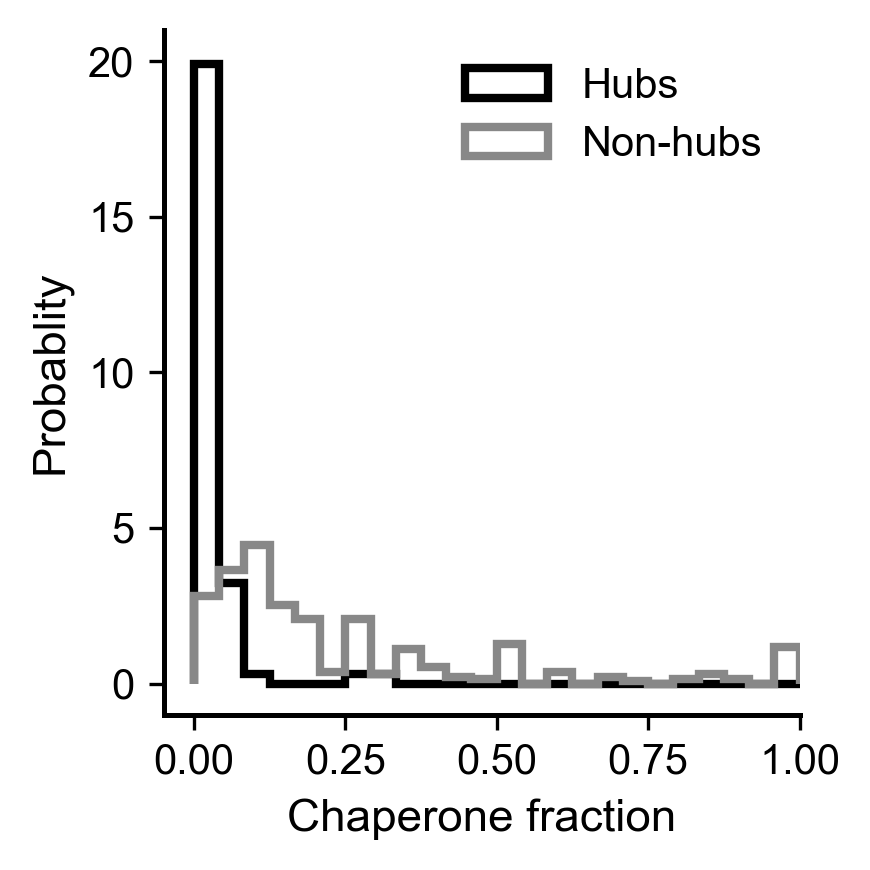

In [45]:
fig, ax = plt.subplots(figsize=(3, 3))

bins = np.linspace(
    0,
    max(hub_nz.max(), nonhub_nz.max()),
    25
)

ax.hist(
    hub_nz,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color='black',
    label="Hubs"
)

ax.hist(
    nonhub_nz,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color='#888888',
    label="Non-hubs"
)

ax.set_xlabel("Chaperone fraction", fontsize=11)
ax.set_ylabel("Probablity", fontsize=11)
ax.set_xlim(-0.05, 1)
ax.set_ylim(-1, 21)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("6a-1.svg")
plt.show()


* Create histograms to visualise distribution of chaperone fraction (%) for hubs and non-hubs across AE-MS dataset

In [52]:
# Extract static and dynamic hubs
static_df  = final_df[final_df["hub_type"] == "static"].copy()
dynamic_df = final_df[final_df["hub_type"] == "dynamic"].copy()

# Clean values
static_frac = static_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_frac = dynamic_df["chaperone_fraction"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()


# Extract chaperone fraction for static vs dynamic hubs 
static_frac = static_frac / 100
dynamic_frac = dynamic_frac / 100

static_frac_nz  = static_frac[static_frac > 0]
dynamic_frac_nz = dynamic_frac[dynamic_frac > 0]

# Optional sanity check
print(f"Static hubs:  {len(static_frac_nz)}/{len(static_frac)} non-zero")
print(f"Dynamic hubs: {len(dynamic_frac_nz)}/{len(dynamic_frac)} non-zero")

static_hub_pct_nz = 100 * len(static_frac_nz) / len(static_frac)
dynamic_hub_pct_nz = 100 * len(dynamic_frac_nz) / len(dynamic_frac)

print(f"Static hubs:     {static_hub_pct_nz:.2f}% have non-zero chaperone fraction")
print(f"Dynamic hubs: {dynamic_hub_pct_nz:.2f}% have non-zero chaperone fraction")


# MWU test — Hub+Chap vs Hub+NoChap - two-sided
ms_u, ms_p = mannwhitneyu(static_frac_nz, dynamic_frac_nz, alternative="two-sided")

print("=== Mann–Whitney U tests on Static and Dynamic hubs (chaperone fraction) ===")

print("\nStatic hubs + Chaperone vs Dynamic Hubs + Chaperone")
print(f"n(static)  = {len(static_frac_nz)}, n(dynamic) = {len(dynamic_frac_nz)}")
print(f"median(static) = {np.median(static_frac_nz):.2f}, median(dynamic) = {np.median(dynamic_frac_nz):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# Mean boolean (≥1 chaperone contact)
print("Static hubs median:", 
      (final_df[final_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean())

print("Dynamic hubs median:", 
      (final_df[final_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean())

# MWU test — Hub+Chap vs Hub+NoChap - one-sided
ms_u, ms_p = mannwhitneyu(static_frac_nz, dynamic_frac_nz, alternative="less")

print("=== Mann–Whitney U tests on Static and Dynamic hubs (chaperone fraction) ===")

print("\nStatic hubs + Chaperone vs Dynamic Hubs + Chaperone")
print(f"n(static)  = {len(static_frac_nz)}, n(dynamic) = {len(dynamic_frac_nz)}")
print(f"median(static) = {np.median(static_frac_nz):.2f}, median(dynamic) = {np.median(dynamic_frac_nz):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# Mean boolean (≥1 chaperone contact)
print("Static hubs median:", 
      (final_df[final_df["hub_type"] == "static"]["num_chaperone_interactions"] > 0).mean())

print("Dynamic hubs median:", 
      (final_df[final_df["hub_type"] == "dynamic"]["num_chaperone_interactions"] > 0).mean())

Static hubs:  26/134 non-zero
Dynamic hubs: 56/118 non-zero
Static hubs:     19.40% have non-zero chaperone fraction
Dynamic hubs: 47.46% have non-zero chaperone fraction
=== Mann–Whitney U tests on Static and Dynamic hubs (chaperone fraction) ===

Static hubs + Chaperone vs Dynamic Hubs + Chaperone
n(static)  = 26, n(dynamic) = 56
median(static) = 0.02, median(dynamic) = 0.02
U = 892.00, p = 0.1032
Static hubs median: 0.19402985074626866
Dynamic hubs median: 0.4745762711864407
=== Mann–Whitney U tests on Static and Dynamic hubs (chaperone fraction) ===

Static hubs + Chaperone vs Dynamic Hubs + Chaperone
n(static)  = 26, n(dynamic) = 56
median(static) = 0.02, median(dynamic) = 0.02
U = 892.00, p = 0.9494
Static hubs median: 0.19402985074626866
Dynamic hubs median: 0.4745762711864407


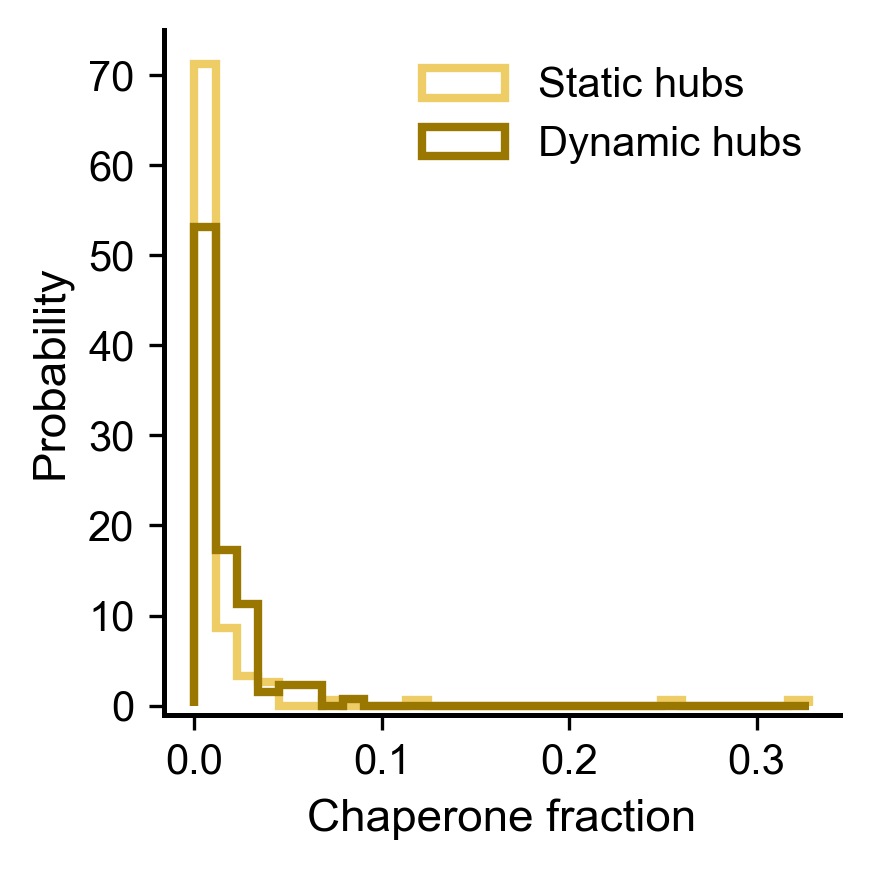

In [50]:

fig, ax = plt.subplots(figsize=(3, 3))

bins = np.linspace(
    0,
    max(static_frac.max(), dynamic_frac.max()),
    30
)

ax.hist(
    static_frac,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color=MS_COLOR_LIGHT,
    label="Static hubs"
)

ax.hist(
    dynamic_frac,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    linestyle="-",
    color=MS_COLOR_DARK,
    label="Dynamic hubs"
)

ax.set_xlabel("Chaperone fraction", fontsize=11)
ax.set_ylabel("Probability", fontsize=11)
#ax.set_xlim(-0.1, 0.35)
ax.set_ylim(-1, 75)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("6a-2.svg")
plt.show()

## Figure 6B

* Boxplot of Turnover kinetics (t1/2 min) of chaperone associated hubs and chaperone independent hubs

In [12]:
def bootstrap_ci_median(values, B=1_000_000, ci=95, random_state=27):
    """
    Nonparametric bootstrap CI for the median.

    values: 1D array-like
    B: number of bootstrap resamples
    ci: confidence level (e.g., 95)
    """
    vals = np.asarray(values)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    medians = np.empty(B, dtype=float)

    # Loop-based bootstrap to avoid large memory allocations
    for b in trange(B, desc="Bootstrapping medians"):
        sample = rng.choice(vals, size=n, replace=True)
        medians[b] = np.median(sample)

    median_hat = np.median(vals)
    alpha = 100 - ci
    lower = np.percentile(medians, alpha / 2)
    upper = np.percentile(medians, 100 - alpha / 2)
    return median_hat, lower, upper
    
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

halflife_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
halflife_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", halflife_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", halflife_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75440.31it/s]


Hub + Chaperone: median=91.80, 95% CI=(91.20, 92.40), n=67)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69255.06it/s]


Hub + No Chaperone: median=88.80, 95% CI=(77.40, 91.20), n=157)


In [13]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")


# ONE-SIDED MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(halflife_hub_chap, halflife_hub_nochap, alternative="greater")

print("=== Mann–Whitney U tests on Villen_halflife_min ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(halflife_hub_chap)}, n(nochap) = {len(halflife_hub_nochap)}")
print(f"median(chap) = {np.median(halflife_hub_chap):.2f}, median(nochap) = {np.median(halflife_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.03492
=== Mann–Whitney U tests on Villen_halflife_min ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 67, n(nochap) = 157
median(chap) = 91.80, median(nochap) = 88.80
U = 6196.50, p = 0.01746


/tmp/ipykernel_4101/2459137529.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


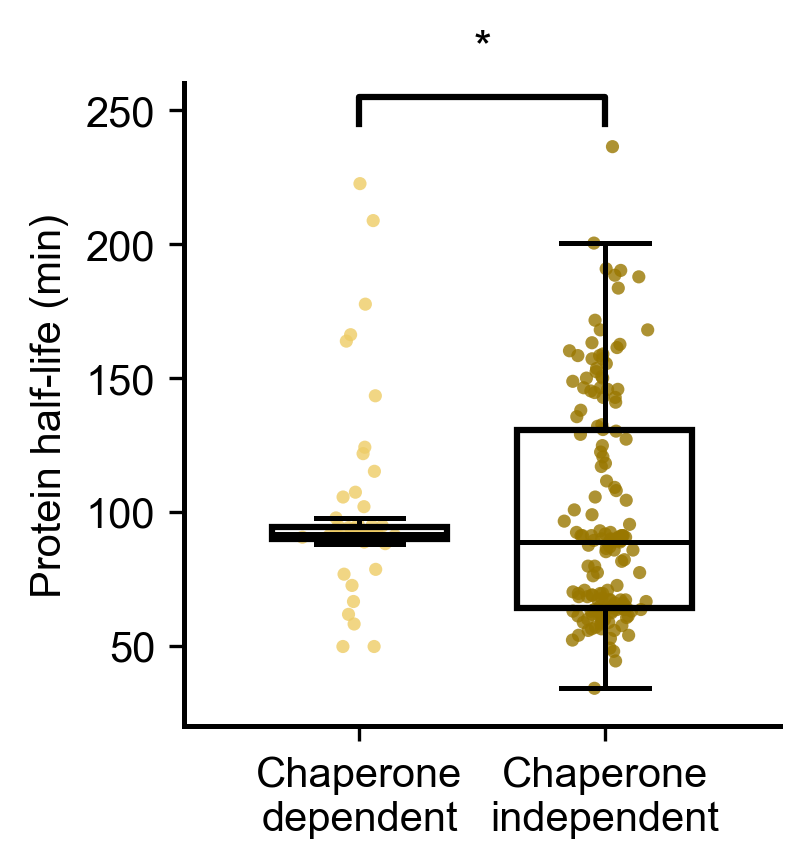

In [14]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 10
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 10,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [halflife_hub_chap, halflife_hub_nochap]
group_colors = [MS_COLOR_LIGHT, MS_COLOR_DARK]

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)
        
#ax.set_yscale("log")
# Correct log ticks (10^1, 10^2, 10^3...)
#ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
#ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
#ax.yaxis.set_minor_locator(ticker.NullLocator())


# --- LOG SCALE with compressed bottom ---
#ax.set_yscale("symlog", linthresh=130)
bracket_y = 245
ax.set_ylim(20, 260)


# --- Axes styling ---
ax.set_ylabel('Protein half-life (min)')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)


# Set clean y-limits: from 0 down to a bit below the lowest value
y_min = min(halflife_hub_chap.min(), halflife_hub_nochap.min())
y_max = max(halflife_hub_chap.max(), halflife_hub_nochap.max())

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "*")

# === Horizontal line + label EXACTLY ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.24, -0.24],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.28, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6b-1.svg")
plt.show()

* Boxplot of Turnover kinetics (t1/2 min) of chaperone associated static and dynamic hubs

In [15]:
# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Villen_halflife_min"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")
 
# Bootstrapped medians 
print("\n=== Bootstrapped median half-life (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f}, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 102
Dynamic + Chap    : n = 46
Dynamic + NoChap  : n = 55

=== Bootstrapped median half-life (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77537.26it/s]


Static + Chap     : median = 91.8, 95% CI = (91.2, 105.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71550.01it/s]


Static + NoChap   : median = 90.6, 95% CI = (81.6, 117.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74897.28it/s]


Dynamic + Chap    : median = 91.2, 95% CI = (90.6, 92.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74901.88it/s]


Dynamic + NoChap  : median = 72.6, 95% CI = (63.6, 90.0)


In [16]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")

# ONE-SIDED Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.215, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000908, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0829, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.00055, significance=***

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1256.0, p=0.107, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1751.5, p=0.000454, significance=***
Static+Chap vs Dynamic+Chap   : U=611.5, p=0.0414, significance=*
Static+NoChap vs Dynamic+NoChap: U=3744.5, p=0.000275, significance=***


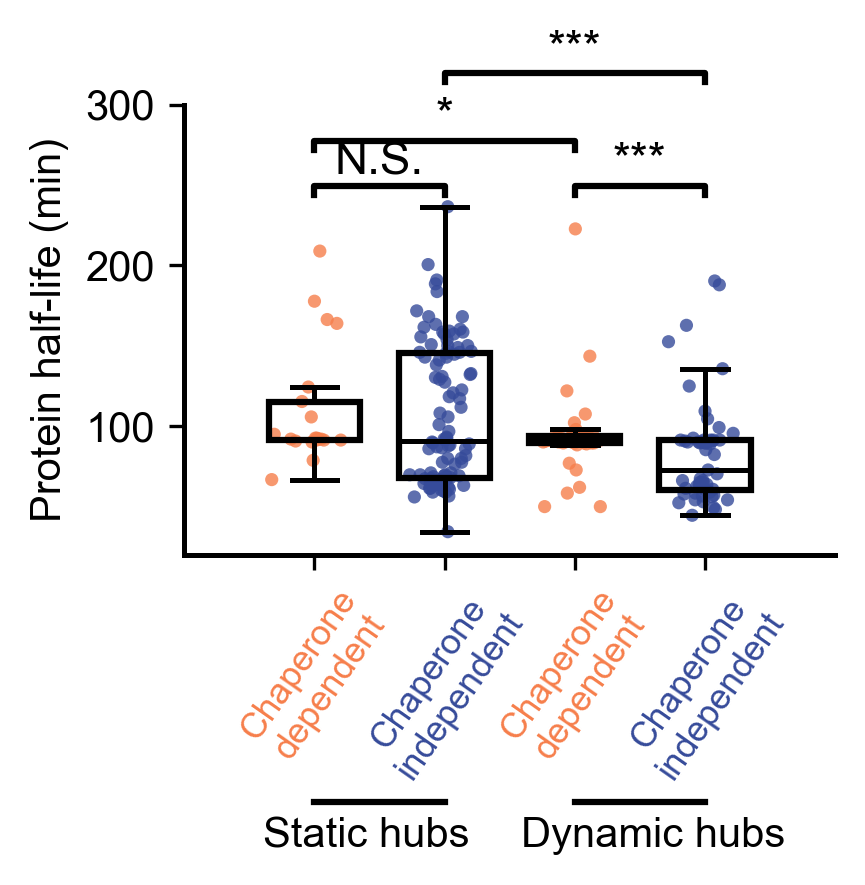

In [17]:
def add_bracket_axis(ax, x1, x2, y_axis, text):
    """
    Draw a bracket in AXIS coordinates.
    y_axis is a fraction of axis height (1.0 = top of plot).
    """
    trans = ax.get_xaxis_transform()  # x = data coords, y = axis coords (0–1)

    # bracket lines
    ax.plot([x1, x1, x2, x2],
            [y_axis, y_axis + 0.02, y_axis + 0.02, y_axis],
            transform=trans,
            lw=1.5, color="black", clip_on=False)

    # label
    ax.text((x1 + x2) / 2, y_axis + 0.025, text,
            transform=trans,
            ha="center", va="bottom",
            fontsize=11, clip_on=False)


fig, ax = plt.subplots(figsize=(2.8, 3))

positions = [0.7, 1.2, 1.7, 2.2]

group_data   = [static_chap, static_nochap, dynamic_chap, dynamic_nochap]
group_colors = ['#F67E4B', '#364B9A', '#F67E4B', '#364B9A']
group_labels = [
    "Chaperone\ndependent",
    "Chaperone\nindependent",
    "Chaperone\ndependent",
    "Chaperone\nindependent"
]

ax.set_xticks(positions)
ax.set_xticklabels(
    ["Chaperone\ndependent",
     "Chaperone\nindependent",
     "Chaperone\ndependent",
     "Chaperone\nindependent"],
    fontsize=10
)

# SCATTER 
for pos, (vals, color) in zip(positions, zip(group_data, group_colors)):
    jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        jitter, vals,
        s=10,
        alpha=0.8,          
        color=color,
        edgecolor="none",
        zorder=2
    )

# BOXPLOTS 
bp = ax.boxplot(
    group_data,
    positions=positions,
    widths=0.35,           
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Y-AXIS STYLE 
#ax.set_yscale("symlog", linthresh=100)
ax.set_ylim(20, 300)
#ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
#ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(base=10))
#ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10), numticks=999))

ax.set_ylabel('Protein half-life (min)', fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.set_xticks(positions)
ax.set_xticklabels(group_labels, fontsize=8.5, ha="center", rotation=55)

for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

#AXIS-BASED SIGNIFICANCE BRACKETS
# lowest brackets (pairwise)
add_bracket_axis(ax, positions[0], positions[1], 0.80, stars_static)
add_bracket_axis(ax, positions[2], positions[3], 0.80, stars_dynamic)

# middle bracket (cross-chaperone)
add_bracket_axis(ax, positions[0], positions[2], 0.9, stars_chap)

# top bracket (cross-independent)
add_bracket_axis(ax, positions[1], positions[3], 1.05, stars_nochap)

# GROUP LABELS AT BOTTOM 
trans = ax.get_xaxis_transform()

ax.plot(
    [0.7, 1.2], [-0.55, -0.55], transform=trans, clip_on=False, color='black', lw=1.5)
ax.text(0.9, -0.65, "Static hubs",
        transform=trans, ha="center", fontsize=10, fontweight="normal")

ax.plot(
    [1.7, 2.2], [-0.55, -0.55], transform=trans, clip_on=False, color='black', lw=1.5)
ax.text(2.0, -0.65, "Dynamic hubs",
        transform=trans, ha="center", fontsize=10, fontweight="normal")

plt.subplots_adjust(bottom=0.38)
plt.savefig("6b-2.svg", dpi=300, bbox_inches="tight")
plt.show()

## Figure 6c

* Boxplot of stability (Ghosh–Dill ΔG) of chaperone associated hubs and chaperone independent hubs

In [18]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74471.12it/s]


Hub + Chaperone: median=-7.15, 95% CI=(-8.14, -6.82), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 68764.32it/s]

Hub + No Chaperone: median=-8.45, 95% CI=(-9.03, -8.09), n=170)


In [19]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on Ghosh-Dill-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.01669
=== Mann–Whitney U tests on Ghosh-Dill-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -7.15, median(nochap) = -8.45
U = 8268.00, p = 0.9917


/tmp/ipykernel_4101/459347788.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


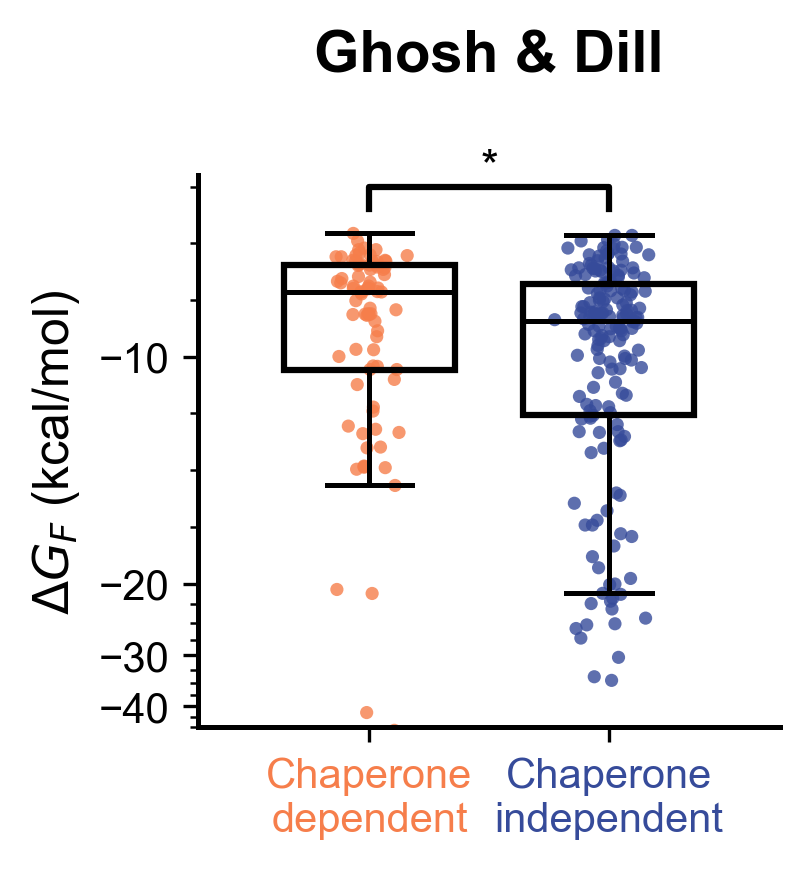

In [20]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# Axes styling
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Ghosh & Dill", fontweight='bold')
ax.set_yscale("symlog", linthresh=20)
ax.set_ylim(-45, -2)
ax.set_yticks([-10, -20, -30, -40])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
#ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
bracket_y = -3.5
bracket_h = -0.05

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label EXACTLY ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.20, -0.20],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.24, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6c-2.svg")
plt.show()

Boxplot of stability (Cagiada ΔG) of chaperone associated hubs and chaperone independent hubs

In [21]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74089.33it/s]


Hub + Chaperone: median=-9.99, 95% CI=(-11.36, -8.06), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69274.26it/s]

Hub + No Chaperone: median=-12.86, 95% CI=(-13.79, -10.93), n=170)


In [22]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on cagiada-dG ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.3003
=== Mann–Whitney U tests on cagiada-dG ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -9.99, median(nochap) = -12.86
U = 7532.00, p = 0.8503


/tmp/ipykernel_4101/438004129.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


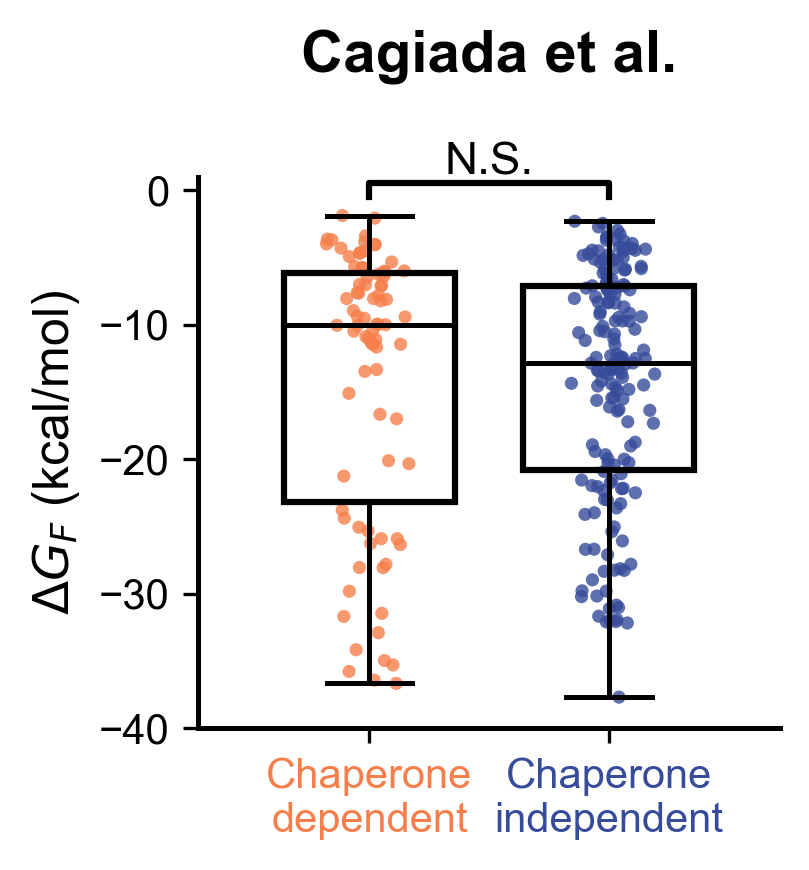

In [23]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 1
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top * 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel(r"$\Delta G_F$ (kcal/mol)", fontsize=12)
ax.set_title("Cagiada et al.", fontweight='bold')
ax.set_ylim(-40, 1)
ax.set_yticks([0, -10, -20, -30, -40])
bracket_y = -0.5
bracket_h = -0.5

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.20, -0.20],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.24, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6c-3.svg")
plt.show()

Boxplot of stability (Rosetta Total Score) of chaperone associated hubs and chaperone independent hubs

In [24]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY 
hub_df = final_df[final_df["is_hub"] == True].copy()

rosetta_hub_chap     = hub_df[hub_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
rosetta_hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups
groups = [
    ("Hub + Chaperone", rosetta_hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", rosetta_hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74186.30it/s]


Hub + Chaperone: median=-537.69, 95% CI=(-669.16, -451.99), n=82)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 69053.27it/s]

Hub + No Chaperone: median=-746.83, 95% CI=(-816.20, -654.67), n=170)


In [25]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")


# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(rosetta_hub_chap, rosetta_hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on Rosetta_best_total_score ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(rosetta_hub_chap)}, n(nochap) = {len(rosetta_hub_nochap)}")
print(f"median(chap) = {np.median(rosetta_hub_chap):.2f}, median(nochap) = {np.median(rosetta_hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.03524
=== Mann–Whitney U tests on Rosetta_best_total_score ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 82, n(nochap) = 170
median(chap) = -537.69, median(nochap) = -746.83
U = 8112.00, p = 0.9825


/tmp/ipykernel_4101/1301826426.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


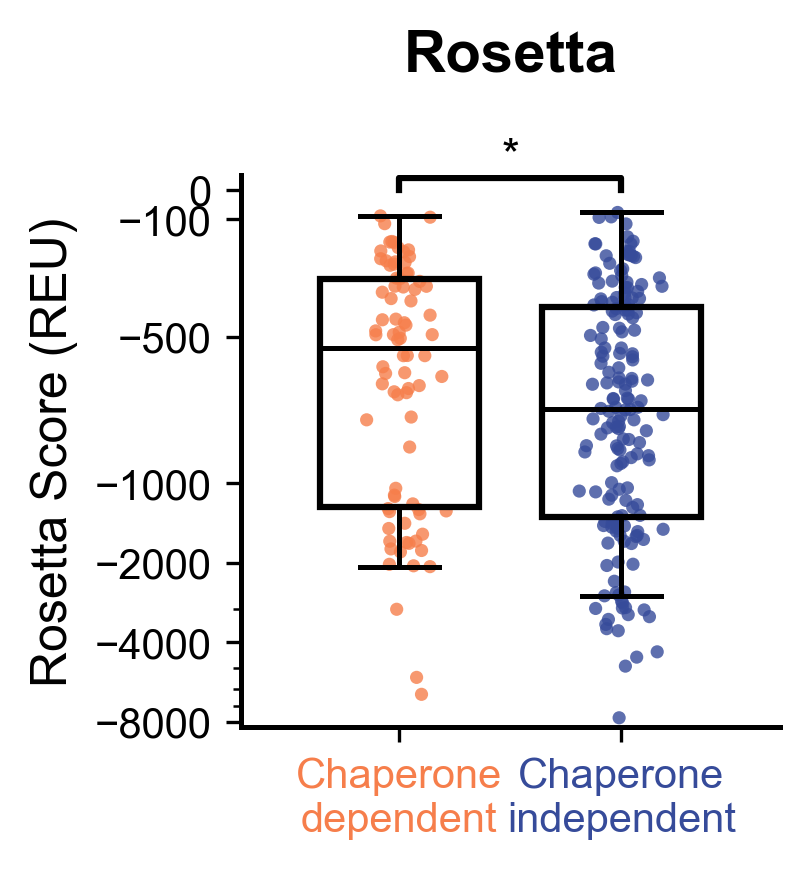

In [26]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 40
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top / 1.05,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [rosetta_hub_chap, rosetta_hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Rosetta Score (REU)", fontsize=12)
ax.set_title("Rosetta", fontweight='bold')
ax.set_yscale("symlog", linthresh=1000)
ax.set_ylim(-8400, 50)
ax.set_yticks([-8000, -4000, -2000, -1000, -500, -100, 0])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
#ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
bracket_y = 0   
bracket_h = 4

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Place significance bracket at a fixed, nice height just above 0
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "N.S.")

# === Horizontal line + label ==
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.22, -0.22],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.26, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6c-1.svg")
plt.show()

Boxplot of Meltome melting point of chaperone associated hubs and chaperone independent hubs

In [27]:
# Create a boolean for chaperone interaction
final_df["has_chaperone"] = final_df["num_chaperone_interactions"] > 0

# HUBS ONLY (degree-based MS hubs already computed)
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Ghosh–Dill values
hub_df["meltome-melting-point"] = hub_df[hub_df['meltome-fit-R2'] > 0.9]["meltome-melting-point"].replace([np.inf, -np.inf], np.nan).dropna()

hub_chap     = hub_df[hub_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()
hub_nochap   = hub_df[hub_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Groups: (label, data, color)
groups = [
    ("Hub + Chaperone", hub_chap, MS_COLOR_LIGHT),
    ("Hub + No Chaperone", hub_nochap, MS_COLOR_DARK),
]

# 2. Compute bootstrapped medians + CIs
medians = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []

for label, vals, color in groups:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, ci=95, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    labels.append(label)
    colors.append(color)
    print(f"{label}: median={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={len(vals)})")

medians = np.array(medians)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# Convert to yerr format for Matplotlib: [lower_err, upper_err]
yerr = np.vstack([medians - ci_lowers, ci_uppers - medians])

Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74855.82it/s]


Hub + Chaperone: median=42.96, 95% CI=(42.37, 44.72), n=69)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 71381.49it/s]

Hub + No Chaperone: median=44.91, 95% CI=(44.31, 47.51), n=109)


In [28]:
# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="two-sided")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

# MWU test — Hub+Chap vs Hub+NoChap
ms_u, ms_p = mannwhitneyu(hub_chap, hub_nochap, alternative="less")

print("=== Mann–Whitney U tests on meltome-melting-point ===")

print("\nMS Hub - Chaperone  associated vs MS Hub - Chaperone  independent")
print(f"n(chap) = {len(hub_chap)}, n(nochap) = {len(hub_nochap)}")
print(f"median(chap) = {np.median(hub_chap):.2f}, median(nochap) = {np.median(hub_nochap):.2f}")
print(f"U = {ms_u:.2f}, p = {ms_p:.4g}")

=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0004195
=== Mann–Whitney U tests on meltome-melting-point ===

MS Hub - Chaperone  associated vs MS Hub - Chaperone  independent
n(chap) = 69, n(nochap) = 109
median(chap) = 42.96, median(nochap) = 44.91
U = 2578.50, p = 0.0002098


/tmp/ipykernel_4101/1963182460.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


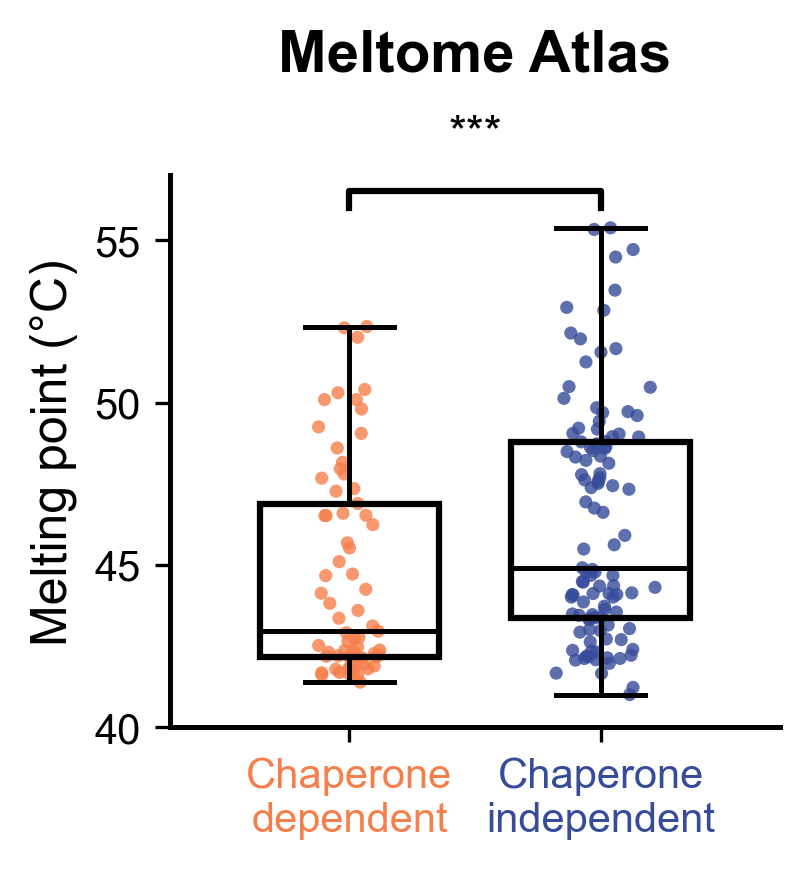

In [29]:
# Plot annotations
def add_bracket_with_text(ax, x1, x2, y, text):
    y_top = y + 0.5
    ax.plot(
        [x1, x1, x2, x2],
        [y,  y_top, y_top, y],
        lw=1.5,
        c="black",
        zorder=4,
    )
    ax.text(
        (x1 + x2) / 2,
        y_top + 1.1,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
        zorder=4,
    )
    
fig, ax = plt.subplots(figsize=(2.8, 3))

group_vals   = [hub_chap, hub_nochap]
group_colors = ['#F67E4B', '#364B9A']

# --- Scatter first (lower zorder) ---
positions = [1, 1.7]
for pos, (vals, color) in zip(positions, zip(group_vals, group_colors)):
    x_jitter = pos + np.random.normal(0, 0.05, size=len(vals))
    ax.scatter(
        x_jitter,
        vals,
        s=10,
        alpha=0.8,
        color=color,
        edgecolor="none",
        zorder=2,
    )

# --- Boxplots on top: outlines only, no fill, no fliers ---
bp = ax.boxplot(
    group_vals,
    labels=["Chaperone\ndependent", "Chaperone\nindependent"],
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

# Color x-axis tick labels
for label, color in zip(ax.get_xticklabels(), group_colors):
    label.set_color(color)

for box in bp["boxes"]:
    box.set_facecolor("none")
    box.set_edgecolor("black")
    box.set_linewidth(1.5)
    box.set_zorder(3)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(1.2)
        line.set_zorder(3)

# --- Axes styling ---
ax.set_ylabel("Melting point (°C)", fontsize=12)
ax.set_title("Meltome Atlas", fontweight='bold')
ax.set_ylim(40, 57)
ax.set_yticks([40, 45, 50, 55])
bracket_y = 56
bracket_h = 0.05

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# # Draw bracket
add_bracket_with_text(ax, positions[0], positions[1], bracket_y, "**")

# === Horizontal line + label ===
# Use x-axis transform so these sit below the x-axis, not in data (log) space
trans = ax.get_xaxis_transform()

# AE-MS group label under x-axis
#ax.plot(
#    [1.0, 1.7], [-0.24, -0.24],
#    transform=trans,
#    clip_on=False,
#    color=MS_COLOR,
#    lw=1.5,
#)

#ax.text(
#    1.35, -0.28, "AE-MS Hubs",
#    transform=trans,
#    ha="center",
#    va="top",
#    fontsize=10,
#    fontweight="bold",
#    color=MS_COLOR,
#)

plt.xticks(fontsize=10)
plt.tight_layout()
plt.savefig("6c-4.svg")
plt.show()

In [30]:
# Prepare Static/Dynamic + Chaperone Groups for Melting point Tm

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Filter Meltome to high-confidence fits
hub_df = hub_df[hub_df["meltome-fit-R2"] > 0.9].copy()

# Convert meltome to numeric and clean
hub_df["meltome-melting-point"] = pd.to_numeric(
    hub_df["meltome-melting-point"], errors="coerce"
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["meltome-melting-point"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 21
Static + NoChap   : n = 61
Dynamic + Chap    : n = 48
Dynamic + NoChap  : n = 48

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77551.33it/s]


Static + Chap     : median = 45.7 °C, 95% CI = (42.3, 47.4)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76417.81it/s]


Static + NoChap   : median = 47.4 °C, 95% CI = (44.7, 48.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 76988.21it/s]


Dynamic + Chap    : median = 42.7 °C, 95% CI = (42.2, 44.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 75900.07it/s]

Dynamic + NoChap  : median = 44.1 °C, 95% CI = (43.3, 46.6)


In [31]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=454.5, p=0.0488, significance=*
Dynamic+Chap vs Dynamic+NoChap: U=886.5, p=0.0522, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=582.5, p=0.309, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1909.0, p=0.00666, significance=**

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=454.5, p=0.976, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=886.5, p=0.974, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=582.5, p=0.155, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=1909.0, p=0.00333, significance=**


In [32]:
# Prepare Static/Dynamic + Chaperone Groups for Rosetta Total Score

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["Rosetta_best_total_score"] = (
    pd.to_numeric(hub_df["Rosetta_best_total_score"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Rosetta_best_total_score"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")


# Bootstrapped medians 
print("\n=== Bootstrapped median Rosetta_best_total_score (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median Rosetta_best_total_score (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:12<00:00, 77601.01it/s]


Static + Chap     : median = -779.1 kcal/mol, 95% CI = (-1260.1, -348.9)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72423.09it/s]


Static + NoChap   : median = -749.3 kcal/mol, 95% CI = (-910.1, -653.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73571.59it/s]


Dynamic + Chap    : median = -493.5 kcal/mol, 95% CI = (-584.1, -428.0)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 71775.16it/s]

Dynamic + NoChap  : median = -728.1 kcal/mol, 95% CI = (-821.1, -557.6)


In [33]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1454.0, p=0.781, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2040.0, p=0.102, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=575.0, p=0.129, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2951.0, p=0.199, significance=N.S.

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1454.0, p=0.39, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2040.0, p=0.051, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=575.0, p=0.937, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2951.0, p=0.901, significance=N.S.


In [34]:
# Prepare Static/Dynamic + Chaperone Groups for Cagiada-dG

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean Rosetta score column ONCE
hub_df["cagiada-dG"] = (
    pd.to_numeric(hub_df["cagiada-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["cagiada-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median cagiada-dG (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} kcal/mol, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median cagiada-dG (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 76038.46it/s]


Static + Chap     : median = -14.3 kcal/mol, 95% CI = (-24.4, -9.6)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 71297.43it/s]


Static + NoChap   : median = -13.5 kcal/mol, 95% CI = (-16.2, -11.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72871.36it/s]


Dynamic + Chap    : median = -9.2 kcal/mol, 95% CI = (-10.3, -7.1)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 73171.08it/s]


Dynamic + NoChap  : median = -12.4 kcal/mol, 95% CI = (-13.2, -9.2)


In [35]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1281.0, p=0.491, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1942.0, p=0.268, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=522.0, p=0.0406, significance=*
Static+NoChap vs Dynamic+NoChap: U=2824.0, p=0.0901, significance=N.S.

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1281.0, p=0.756, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=1942.0, p=0.134, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=522.0, p=0.98, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2824.0, p=0.955, significance=N.S.


In [36]:
# Prepare Static/Dynamic + Chaperone Groups for Ghosh-Dill-dG

# Hubs only
hub_df = final_df[final_df["is_hub"] == True].copy()

# Clean column ONCE
hub_df["Ghosh-Dill-dG"] = (
    pd.to_numeric(hub_df["Ghosh-Dill-dG"], errors='coerce')
      .replace([np.inf, -np.inf], np.nan)
)

# Static vs Dynamic subsets
static_df  = hub_df[hub_df["hub_type"] == "static"].copy()
dynamic_df = hub_df[hub_df["hub_type"] == "dynamic"].copy()

# Clean values (replace inf, nan)
static_chap = static_df[static_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

static_nochap = static_df[static_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_chap = dynamic_df[dynamic_df["has_chaperone"] == True]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

dynamic_nochap = dynamic_df[dynamic_df["has_chaperone"] == False]["Ghosh-Dill-dG"]\
                    .replace([np.inf, -np.inf], np.nan).dropna()

# Print counts 
groups_step3 = [
    ("Static + Chap",    static_chap,    MS_COLOR_LIGHT),
    ("Static + NoChap",  static_nochap,  MS_COLOR_DARK),
    ("Dynamic + Chap",   dynamic_chap,   MS_COLOR_LIGHT),
    ("Dynamic + NoChap", dynamic_nochap, MS_COLOR_DARK),
]

print("=== Protein counts in Degree Hubs (MS) ===")
for label, vals, _ in groups_step3:
    print(f"{label:18}: n = {len(vals)}")

# Bootstrapped medians 
print("\n=== Bootstrapped median meltome-melting-point (95% CI) ===")
medians, ci_lowers, ci_uppers = [], [], []

for label, vals, color in groups_step3:
    m, lo, hi = bootstrap_ci_median(vals, B=1_000_000, random_state=42)
    medians.append(m)
    ci_lowers.append(lo)
    ci_uppers.append(hi)
    print(f"{label:18}: median = {m:.1f} °C, 95% CI = ({lo:.1f}, {hi:.1f})")

=== Protein counts in Degree Hubs (MS) ===
Static + Chap     : n = 26
Static + NoChap   : n = 108
Dynamic + Chap    : n = 56
Dynamic + NoChap  : n = 62

=== Bootstrapped median meltome-melting-point (95% CI) ===


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 72265.50it/s]


Static + Chap     : median = -9.0 °C, 95% CI = (-11.0, -6.2)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:14<00:00, 70539.00it/s]


Static + NoChap   : median = -8.8 °C, 95% CI = (-10.0, -8.3)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74269.39it/s]


Dynamic + Chap    : median = -7.0 °C, 95% CI = (-8.0, -6.7)


Bootstrapping medians: 100%|███████████████████████████████████████████████| 1000000/1000000 [00:13<00:00, 74100.46it/s]

Dynamic + NoChap  : median = -8.1 °C, 95% CI = (-8.5, -7.3)


In [37]:
# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")



# Mann–Whitney U tests
print("\n=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===")

def mwu_print(x, y, label):
    u, p = mannwhitneyu(x, y, alternative="greater")
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "N.S."
    print(f"{label:30}: U={u:.1f}, p={p:.3g}, significance={stars}")
    return stars

# 1. Within Static: Chaperone vs NoChaperone
stars_static = mwu_print(static_chap, static_nochap,
                         "Static+Chap vs Static+NoChap")

# 2. Within Dynamic: Chaperone vs NoChaperone
stars_dynamic = mwu_print(dynamic_chap, dynamic_nochap,
                          "Dynamic+Chap vs Dynamic+NoChap")

# 3. Between types (Chaperone only)
stars_chap = mwu_print(static_chap, dynamic_chap,
                       "Static+Chap vs Dynamic+Chap")

# 4. Between types (NoChaperone only)
stars_nochap = mwu_print(static_nochap, dynamic_nochap,
                         "Static+NoChap vs Dynamic+NoChap")


=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1542.5, p=0.437, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2010.0, p=0.14, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=606.0, p=0.226, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2733.5, p=0.0468, significance=*

=== Mann–Whitney U tests (Static/Dynamic × Chaperone) ===
Static+Chap vs Static+NoChap  : U=1542.5, p=0.219, significance=N.S.
Dynamic+Chap vs Dynamic+NoChap: U=2010.0, p=0.0702, significance=N.S.
Static+Chap vs Dynamic+Chap   : U=606.0, p=0.889, significance=N.S.
Static+NoChap vs Dynamic+NoChap: U=2733.5, p=0.977, significance=N.S.
